# EJD-UMA-004 v8.9 · Naive Bayes Federado con MoG Real + Modelo Hibrido
## Dataset: CIC-IDS2017 — Canadian Institute for Cybersecurity

**Ejercicio doctoral** | Programa de Doctorado en Tecnologias Informaticas  
Universidad de Malaga

**Autor:** Ing. Edgar O. Herrera Logrono, M.Sc. en Inteligencia Artificial, VIU Espana  
**Directores propuestos:** Prof. Ezequiel Lopez Rubio · Prof. Juan Miguel Ortiz de Lazcano

---

| Campo | Detalle |
|-------|---------|
| Version | **9_dev1** (interna) / publica: v8.9 |
| Dataset | CIC-IDS2017 — Canadian Institute for Cybersecurity |
| Fecha | 2026-04-25 |
| Semilla | 42 |
| Basado en | EJD-UMA-003 v8.8 (NSL-KDD, aprobado por directores) |

### Cambios respecto a EJD-UMA-003 v8.8

| Version | Cambio |
|---------|--------|
| v8.8 | NSL-KDD: modelo hibrido + 7 alphas + verificacion categorias |
| **v8.9** | **CIC-IDS2017: dataset de trafico real + max_categorias+1 para categorias nuevas** |

### Correcciones de directores aplicadas desde EJD-UMA-003

**Prof. Ortiz de Lazcano (21-abr-2026):** CategoricalNB para categoricas, GaussianNB para numericas, multiplicacion de probabilidades.

**Prof. Ortiz de Lazcano (24-abr-2026):** max_categorias + 1 para categorias no vistas en test/OOD — correccion critica para datasets nuevos donde el test puede tener categorias no vistas en entrenamiento.

**Prof. Lopez Rubio (20-abr-2026):** 4 propuestas en orden, 7 alphas para gradiente suave, al menos 3 datasets.


In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 0 · Parametros configurables                       ║
# ║  EJD-UMA-004 v8.9 · CIC-IDS2017                         ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Reproducibilidad ─────────────────────────────────────────────────
SEMILLA = 42

# ── Particion de datos ───────────────────────────────────────────────
TEST_SIZE = 0.20
VAL_SIZE  = 0.20

# ── Heterogeneidad Dirichlet — 7 niveles aprobados Prof. Lopez Rubio ─
ALPHAS_DIRICHLET = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

# ── Nodos institucionales ────────────────────────────────────────────
NODOS = ['Financiero', 'Salud', 'Gobierno']

# ── Variables CRISC por nodo (aprobadas en EJD-UMA-003) ─────────────
CRISC = {
    'Financiero': {'CMM': 4, 'KCI': 0.82, 'KRI': 0.12, 'CVSS': 3.2},
    'Salud':      {'CMM': 3, 'KCI': 0.70, 'KRI': 0.25, 'CVSS': 5.1},
    'Gobierno':   {'CMM': 2, 'KCI': 0.55, 'KRI': 0.40, 'CVSS': 6.8},
}

# ── ICC = (CMM/5) * KCI * (1-KRI) * (1-CVSS/10) ────────────────────
ICC = {
    n: (v['CMM']/5) * v['KCI'] * (1-v['KRI']) * (1-v['CVSS']/10)
    for n, v in CRISC.items()
}

# ── Variables categoricas (CategoricalNB) y numericas (GaussianNB) ──
# Aprobado por Prof. Ortiz de Lazcano (21-abr-2026)
# Protocol: categorica (TCP, UDP, etc.)
# Flag counts binarios: categoricos por naturaleza cualitativa
# Resto de estadisticas de flujo: numericas
COLS_CAT_CIC = ['Protocol', 'FIN Flag Count', 'SYN Flag Count',
                 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
                 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count']

# ── Optimizador ──────────────────────────────────────────────────────
LAMBDA = 0.01   # Regularizacion ICC (ajustado en v8.11 de EJD-UMA-003)
PISO_W = 0.10   # Peso minimo por nodo (ajustado en v8.11 de EJD-UMA-003)

# ── Kaggle dataset ───────────────────────────────────────────────────
KAGGLE_DATASET = 'cicdataset/cicids2017'

print('[ OK ] Seccion 0 · Parametros configurados')
print(f'       Semilla             : {SEMILLA}')
print(f'       Test size           : {TEST_SIZE}')
print(f'       Val size            : {VAL_SIZE}')
print(f'       Alphas Dirichlet    : {ALPHAS_DIRICHLET}')
print()
print('       Variables CRISC por nodo:')
for n, icc_val in ICC.items():
    c = CRISC[n]
    print(f'       {n:12s} CMM={c["CMM"]} KCI={c["KCI"]} KRI={c["KRI"]} CVSS={c["CVSS"]} => ICC={icc_val:.4f}')
print()
print(f'       Categoricas CategoricalNB: {COLS_CAT_CIC}')


[ OK ] Seccion 0 · Parametros configurados
       Semilla             : 42
       Test size           : 0.2
       Val size            : 0.2
       Alphas Dirichlet    : [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

       Variables CRISC por nodo:
       Financiero   CMM=4 KCI=0.82 KRI=0.12 CVSS=3.2 => ICC=0.3926
       Salud        CMM=3 KCI=0.7 KRI=0.25 CVSS=5.1 => ICC=0.1543
       Gobierno     CMM=2 KCI=0.55 KRI=0.4 CVSS=6.8 => ICC=0.0422

       Categoricas CategoricalNB: ['Protocol', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count']


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  EJD-UMA-004 v8.9 · Aviso de tiempo estimado            ║
# ╚══════════════════════════════════════════════════════════════╝

print('=' * 65)
print('  EJD-UMA-004 v8.9 · Naive Bayes Federado con MoG Real')
print('  Dataset: CIC-IDS2017 — Canadian Institute for Cybersecurity')
print('  Ing. Edgar O. Herrera Logrono, M.Sc.')
print('=' * 65)
print()
print('  TIEMPO ESTIMADO DE EJECUCION:')
print('  Descarga Kaggle         ~  2-3 min (requiere kaggle.json)')
print('  Limpieza del dataset    ~  3-5 min (duplicados, Inf/NaN, PortScan)')
print('  Preprocesamiento        ~  2-3 min (OrdinalEncoder + StandardScaler)')
print('  PROTOCOLO-STRESS        ~  1-2 min')
print('  Aprendizaje de pesos    ~ 15-25 min (7 alphas x optimizador)')
print('  Evaluacion OOD          ~  2-3 min')
print('  Figuras y conclusiones  ~  1-2 min')
print('  -------------------------------------------------------')
print('  TOTAL ESTIMADO          ~ 30-45 min en Google Colab CPU')
print()
print('  Si tarda mas de 60 min, reinicia el entorno y vuelve a correr.')
print('  Todos los resultados son reproducibles con SEMILLA=42.')
print('=' * 65)


  EJD-UMA-004 v9_dev10 · Naive Bayes Federado con MoG Real
  Dataset: CIC-IDS2017 — Canadian Institute for Cybersecurity
  Ing. Edgar O. Herrera Logrono, M.Sc.

  TIEMPO ESTIMADO DE EJECUCION:
  Descarga Kaggle         ~  2-3 min (requiere kaggle.json)
  Limpieza del dataset    ~  3-5 min (duplicados, Inf/NaN, PortScan)
  Preprocesamiento        ~  2-3 min (OrdinalEncoder + StandardScaler)
  PROTOCOLO-STRESS        ~  1-2 min
  Aprendizaje de pesos    ~ 15-25 min (7 alphas x optimizador)
  Evaluacion OOD          ~  2-3 min
  Figuras y conclusiones  ~  1-2 min
  -------------------------------------------------------
  TOTAL ESTIMADO          ~ 30-45 min en Google Colab CPU

  Si tarda mas de 60 min, reinicia el entorno y vuelve a correr.
  Todos los resultados son reproducibles con SEMILLA=42.


In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 1 · Preparacion del entorno y descarga del dataset ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Leccion aprendida de ejercicios anteriores:
# El programa verifica si el dataset ya existe antes de descargar.
# Si existe, continua sin interrumpir. Si no, lo descarga automaticamente.
# Esto evita errores cuando el entorno de Colab se reinicia.

import os, json, time
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import f1_score
from scipy.stats import entropy
from scipy.optimize import minimize

# ── Rutas del dataset ─────────────────────────────────────────────────
KAGGLE_DATASET = 'sweety18/cicids2017-full-modified-all-8-files'
RUTA_DESCARGA  = '/content/cicids2017_original'
RUTA_CSV       = f'{RUTA_DESCARGA}/combinenew.csv'

# ── Beeps ─────────────────────────────────────────────────────────────
def _beep_colab(frecuencias, duraciones, pausa=0.1):
    try:
        if not os.path.exists('/content'): return
        from IPython.display import Audio as _Audio, display as _display
        sr = 22050; ondas = []
        for freq, dur in zip(frecuencias, duraciones):
            t = np.linspace(0, dur, int(sr * dur))
            ondas.append(np.sin(2 * np.pi * freq * t) * np.exp(-4 * t))
            ondas.append(np.zeros(int(sr * pausa)))
        _display(_Audio(np.concatenate(ondas), rate=sr, autoplay=True))
    except Exception: pass

def beep_fin():
    """Beep doble 432 Hz — programa completado exitosamente."""
    _beep_colab([432, 432], [0.4, 0.4])

def beep_error():
    """Beep triple descendente — programa con error o caida."""
    _beep_colab([660, 440, 220], [0.3, 0.3, 0.5])

# Capturar errores globales
try:
    from IPython import get_ipython as _gip
    _ip = _gip()
    if _ip:
        def _handle_error(shell, etype, evalue, tb, tb_offset=None):
            try: beep_error()
            except Exception: pass
            shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)
        _ip.set_custom_exc((Exception,), _handle_error)
except Exception: pass

print('[ OK ] Beeps configurados: beep_fin() y beep_error()')

# ── Verificacion y descarga inteligente ───────────────────────────────
print()
print('Verificando disponibilidad del dataset...')

if os.path.exists(RUTA_CSV):
    # Dataset ya disponible — no necesita descarga
    tam_mb = os.path.getsize(RUTA_CSV) / (1024*1024)
    print(f'  [OK] Dataset encontrado: {RUTA_CSV} ({tam_mb:.0f} MB)')
    print('  No es necesario descargar — continuando...')
else:
    print(f'  Dataset no encontrado en: {RUTA_CSV}')
    print('  Iniciando descarga desde Kaggle...')

    # Verificar o configurar credenciales Kaggle
    kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
    kaggle_content_path = '/content/kaggle.json'

    if os.path.exists(kaggle_json_path):
        print('  [OK] Credenciales Kaggle ya configuradas')
    elif os.path.exists(kaggle_content_path):
        # El archivo esta en /content — configurar
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        shutil.copy(kaggle_content_path, kaggle_json_path)
        os.chmod(kaggle_json_path, 0o600)
        print('  [OK] Credenciales Kaggle configuradas desde /content/kaggle.json')
    else:
        # Solicitar al usuario que suba el archivo
        print('  Credenciales no encontradas. Por favor sube tu kaggle.json:')
        from google.colab import files
        uploaded = files.upload()
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        with open(kaggle_json_path, 'wb') as f:
            f.write(uploaded['kaggle.json'])
        os.chmod(kaggle_json_path, 0o600)
        print('  [OK] Credenciales configuradas correctamente')

    # Instalar kaggle si es necesario
    os.system('pip install kaggle -q')

    # Descargar dataset
    os.makedirs(RUTA_DESCARGA, exist_ok=True)
    print(f'  Descargando {KAGGLE_DATASET}...')
    resultado = os.system(f'kaggle datasets download -d {KAGGLE_DATASET} --unzip -p {RUTA_DESCARGA}')

    if os.path.exists(RUTA_CSV):
        tam_mb = os.path.getsize(RUTA_CSV) / (1024*1024)
        print(f'  [OK] Descarga completada: {tam_mb:.0f} MB')
    else:
        print('  [!!] Descarga completada pero archivo no encontrado.')
        print(f'  Buscando archivos disponibles en {RUTA_DESCARGA}:')
        import glob as _glob
        for f in _glob.glob(f'{RUTA_DESCARGA}/**/*', recursive=True)[:10]:
            print(f'    {f}')
        raise FileNotFoundError(
            f'No se encontro {RUTA_CSV}. Revisa la ruta arriba.'
        )

print()
print('[ OK ] Seccion 1 · Preparacion del entorno completada')
print(f'       Dataset listo en: {RUTA_CSV}')


[ OK ] Beeps configurados: beep_fin() y beep_error()

Verificando disponibilidad del dataset...
  Dataset no encontrado en: /content/cicids2017_original/combinenew.csv
  Iniciando descarga desde Kaggle...
  Credenciales no encontradas. Por favor sube tu kaggle.json:


Saving kaggle.json to kaggle.json
  [OK] Credenciales configuradas correctamente
  Descargando sweety18/cicids2017-full-modified-all-8-files...
  [OK] Descarga completada: 832 MB

[ OK ] Seccion 1 · Preparacion del entorno completada
       Dataset listo en: /content/cicids2017_original/combinenew.csv


In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 2 · Carga y limpieza del dataset CIC-IDS2017       ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Limpieza requerida segun Lara-Gutierrez (2025) y Lanvin et al. (2022):
# 1. Eliminar flujos duplicados (drop_duplicates)
# 2. Reemplazar infinitos y NaN en Flow Bytes/s y Flow Packets/s
# 3. Correccion de etiquetado en PortScan (Lanvin et al. 2022)
#
# Ruta confirmada: /content/cicids2017_original/combinenew.csv
# Dataset: sweety18/cicids2017-full-modified-all-8-files (Kaggle)
# Registros esperados: ~2.8M | Columnas: 79 | Clases: 15

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import time

_t0 = time.time()

# ── Ruta del dataset descargado ───────────────────────────────────────
RUTA_CSV = '/content/cicids2017_original/combinenew.csv'

print(f'Cargando dataset desde: {RUTA_CSV}')
df_raw = pd.read_csv(RUTA_CSV, low_memory=False)
df_raw.columns = df_raw.columns.str.strip()

print(f'Registros cargados    : {len(df_raw):,}')
print(f'Columnas disponibles  : {len(df_raw.columns)}')

# ── Identificar columna de etiquetas ─────────────────────────────────
LABEL_COL = 'Label'
df_raw = df_raw.copy()
df_raw[LABEL_COL] = df_raw[LABEL_COL].str.strip()

print(f'Columna de etiquetas  : {LABEL_COL}')
df_raw = df_raw.dropna(subset=[LABEL_COL])
print(f'Clases detectadas     : {sorted(df_raw[LABEL_COL].unique())}')

# ── Limpieza 1: Infinitos y NaN ───────────────────────────────────────
for col in ['Flow Bytes/s', 'Flow Packets/s']:
    if col in df_raw.columns:
        n_inf = np.isinf(df_raw[col].values.astype(float)).sum()
        n_nan = df_raw[col].isna().sum()
        if n_inf > 0 or n_nan > 0:
            df_raw = df_raw[~np.isinf(df_raw[col].values.astype(float))]
            df_raw = df_raw.dropna(subset=[col])
            print(f'  {col}: {n_inf} infinitos + {n_nan} NaN eliminados')

# ── Limpieza 2: Duplicados ────────────────────────────────────────────
n_antes = len(df_raw)
df_raw  = df_raw.drop_duplicates()
print(f'Duplicados eliminados : {n_antes - len(df_raw):,}')
print(f'Registros finales     : {len(df_raw):,}')

# ── Mapear clases a indices ───────────────────────────────────────────
le_clase = LabelEncoder()
df_raw['clase_id'] = le_clase.fit_transform(df_raw[LABEL_COL])
clases   = le_clase.classes_
n_clases = len(clases)

print()
print(f'Distribucion de clases:')
for clase, count in df_raw[LABEL_COL].value_counts().items():
    print(f'  {clase:40s}: {count:>8,}')

print()
print(f'Total clases detectadas: {n_clases}')
print(f'Tiempo de carga y limpieza: {time.time()-_t0:.1f} segundos')
print('[ OK ] Seccion 2 · Carga y limpieza del dataset completada')


Cargando dataset desde: /content/cicids2017_original/combinenew.csv
Registros cargados    : 2,830,744
Columnas disponibles  : 79
Columna de etiquetas  : Label
Clases detectadas     : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack_Brute Force', 'Web Attack_Sql Injection', 'Web Attack_XSS']
  Flow Bytes/s: 1479 infinitos + 1358 NaN eliminados
Duplicados eliminados : 329,663
Registros finales     : 2,498,243

Distribucion de clases:
  BENIGN                                  : 2,072,500
  DoS Hulk                                :  172,846
  DDoS                                    :  128,016
  PortScan                                :   90,694
  DoS GoldenEye                           :   10,286
  FTP-Patator                             :    5,931
  DoS slowloris                           :    5,385
  DoS Slowhttptest                        :    5,228
  SSH-Patato

In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 3 · Preprocesamiento hibrido                       ║
# ║  CategoricalNB para categoricas + GaussianNB para numericas ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Aprobado por Prof. Ortiz de Lazcano (21-abr-2026):
# Las variables categoricas (Protocol, flags binarios) se codifican
# con OrdinalEncoder. CategoricalNB no introduce sesgo de distancia.
# Las numericas se escalan con StandardScaler para GaussianNB.
#
# Correccion Prof. Ortiz de Lazcano (24-abr-2026):
# Para datasets nuevos, OrdinalEncoder puede asignar -1 a categorias
# no vistas en entrenamiento. Se usa handle_unknown='use_encoded_value'
# con unknown_value = max_categorias + 1 en lugar de clipear a 0.

# ── Identificar columnas disponibles ─────────────────────────────────
COLS_CAT = [c for c in COLS_CAT_CIC if c in df_raw.columns]
COLS_NUM = [c for c in df_raw.columns
            if c not in COLS_CAT + [LABEL_COL, 'clase_id']
            and df_raw[c].dtype in ['float64', 'int64', 'float32', 'int32']]

print(f'Variables categoricas disponibles ({len(COLS_CAT)}): {COLS_CAT}')
print(f'Variables numericas ({len(COLS_NUM)})')

RASGOS = COLS_CAT + COLS_NUM
N_CAT  = len(COLS_CAT)
N_NUM  = len(COLS_NUM)

# ── Separar X e y ────────────────────────────────────────────────────
X_cat_raw = df_raw[COLS_CAT].astype(str)
X_num_raw = df_raw[COLS_NUM].values.astype(float)
y_all     = df_raw['clase_id'].values

# ── OrdinalEncoder con max_categorias + 1 para categorias nuevas ─────
# Correccion de Prof. Ortiz de Lazcano (24-abr-2026):
# unknown_value = -1 (default) causaria sesgo si se clipeara a 0.
# La correccion correcta es asignar n_categorias (max+1) para lo desconocido.
oe_cat = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1  # Se reemplazara con max+1 en prediccion
)
X_cat_encoded = oe_cat.fit_transform(X_cat_raw)

# Calcular max_categorias por columna para usar en prediccion
max_cats_por_col = np.array([len(cats) for cats in oe_cat.categories_])
print(f'\nCategorias por variable:')
for col, cats in zip(COLS_CAT, oe_cat.categories_):
    print(f'  {col}: {len(cats)} categorias — {list(cats)[:5]}{"..." if len(cats)>5 else ""}')

# ── StandardScaler para numericas ────────────────────────────────────
scaler    = StandardScaler()
X_num_all = scaler.fit_transform(X_num_raw)

# ── Reemplazar -1 con max_categorias en el conjunto completo ─────────
for j in range(N_CAT):
    mask = X_cat_encoded[:, j] < 0
    X_cat_encoded[mask, j] = max_cats_por_col[j]  # max + 1 efectivo

# ── Division train / val / test ───────────────────────────────────────
np.random.seed(SEMILLA)
idx = np.arange(len(y_all))
idx_train_full, idx_test = train_test_split(idx, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y_all)
idx_train, idx_val       = train_test_split(idx_train_full, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=SEMILLA, stratify=y_all[idx_train_full])

X_cat_train = X_cat_encoded[idx_train].astype(int)
X_cat_val   = X_cat_encoded[idx_val].astype(int)
X_cat_test  = X_cat_encoded[idx_test].astype(int)
X_num_train = X_num_all[idx_train]
X_num_val   = X_num_all[idx_val]
X_num_test  = X_num_all[idx_test]
y_train     = y_all[idx_train]
y_val       = y_all[idx_val]
y_test      = y_all[idx_test]

# ── Prior de clase ────────────────────────────────────────────────────
conteo_clases = np.bincount(y_train, minlength=n_clases).astype(float)
LOG_PRIOR     = np.log(conteo_clases / conteo_clases.sum() + 1e-10)

print(f'\nParticion:')
print(f'  X_cat_train : {X_cat_train.shape}  X_num_train : {X_num_train.shape}')
print(f'  X_cat_val   : {X_cat_val.shape}  X_num_val   : {X_num_val.shape}')
print(f'  X_cat_test  : {X_cat_test.shape}  X_num_test  : {X_num_test.shape}')
print('[ OK ] Seccion 3 · Preprocesamiento hibrido completado')


Variables categoricas disponibles (8): ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count']
Variables numericas (69)

Categorias por variable:
  FIN Flag Count: 2 categorias — ['0.0', '1.0']
  SYN Flag Count: 2 categorias — ['0.0', '1.0']
  RST Flag Count: 2 categorias — ['0.0', '1.0']
  PSH Flag Count: 2 categorias — ['0.0', '1.0']
  ACK Flag Count: 2 categorias — ['0.0', '1.0']
  URG Flag Count: 2 categorias — ['0.0', '1.0']
  CWE Flag Count: 2 categorias — ['0.0', '1.0']
  ECE Flag Count: 2 categorias — ['0.0', '1.0']

Particion:
  X_cat_train : (1498945, 8)  X_num_train : (1498945, 69)
  X_cat_val   : (499649, 8)  X_num_val   : (499649, 69)
  X_cat_test  : (499649, 8)  X_num_test  : (499649, 69)
[ OK ] Seccion 3 · Preprocesamiento hibrido completado


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 3.5 · Submuestreo aprobado por Prof. Lopez Rubio   ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Indicacion del Prof. Ezequiel Lopez Rubio (26-abr-2026):
# "Se puede manejar el problema haciendo un submuestreo de las clases
#  mayoritarias, manteniendo todas las muestras de las clases minoritarias.
#  El conjunto de datos reducido podria contener alrededor de 100.000
#  muestras, para mantenerse en el mismo orden de magnitud que NSL-KDD."
#
# Criterio de aplicacion:
# - Clases minoritarias (menos de 1,000 muestras): se mantienen TODAS
# - Clases mayoritarias (mas de 1,000 muestras): se limitan a una cuota
#   proporcional para llegar a ~100,000 muestras en total

import numpy as np
from sklearn.model_selection import train_test_split

OBJETIVO_TOTAL = 100_000
UMBRAL_MINORITARIA = 1_000  # Clases con menos de esto se conservan completas

print('╔' + '═'*70 + '╗')
print('║  SUBMUESTREO APROBADO POR PROF. LOPEZ RUBIO (26-abr-2026)       ║')
print('╚' + '═'*70 + '╝')
print()
print(f'  Objetivo total      : {OBJETIVO_TOTAL:,} muestras')
print(f'  Umbral minoritaria  : {UMBRAL_MINORITARIA:,} muestras')
print()

# Identificar clases mayoritarias y minoritarias
conteo_original = np.bincount(y_all, minlength=n_clases)
clases_minoritarias = [c for c in range(n_clases) if conteo_original[c] <= UMBRAL_MINORITARIA]
clases_mayoritarias = [c for c in range(n_clases) if conteo_original[c] > UMBRAL_MINORITARIA]

print('  Clases MINORITARIAS (se mantienen TODAS):')
total_minoritarias = 0
for c in clases_minoritarias:
    print(f'    {clases[c]:40s}: {conteo_original[c]:>6,} muestras')
    total_minoritarias += conteo_original[c]

print()
print('  Clases MAYORITARIAS (se aplicara cuota):')
for c in clases_mayoritarias:
    print(f'    {clases[c]:40s}: {conteo_original[c]:>6,} muestras')

# Calcular cuota para mayoritarias
muestras_disponibles_mayoritarias = OBJETIVO_TOTAL - total_minoritarias
n_mayoritarias = len(clases_mayoritarias)
cuota_por_clase = muestras_disponibles_mayoritarias // n_mayoritarias

print()
print(f'  Muestras para minoritarias : {total_minoritarias:,}')
print(f'  Muestras para mayoritarias : {muestras_disponibles_mayoritarias:,}')
print(f'  Cuota por clase mayoritaria: {cuota_por_clase:,}')

# Construir indice final
np.random.seed(SEMILLA)
indices_finales = []

for c in range(n_clases):
    idx_clase = np.where(y_all == c)[0]
    if c in clases_minoritarias:
        # Conservar todas
        indices_finales.extend(idx_clase.tolist())
    else:
        # Aplicar cuota
        n_tomar = min(cuota_por_clase, len(idx_clase))
        idx_seleccionados = np.random.choice(idx_clase, n_tomar, replace=False)
        indices_finales.extend(idx_seleccionados.tolist())

indices_finales = np.array(indices_finales)
np.random.shuffle(indices_finales)

print()
print(f'  Total muestras seleccionadas: {len(indices_finales):,}')
print()
print('  Distribucion final:')
for c in range(n_clases):
    n_c = int((y_all[indices_finales] == c).sum())
    tipo = 'minoritaria' if c in clases_minoritarias else 'mayoritaria'
    print(f'    {clases[c]:40s}: {n_c:>6,}  ({tipo})')

# Aplicar submuestreo
X_cat_sub = X_cat_encoded[indices_finales].astype(int)
X_num_sub = X_num_all[indices_finales]
y_sub     = y_all[indices_finales]

# Reparticion train/val/test sobre el subconjunto
idx_sub = np.arange(len(y_sub))
idx_tr_sub, idx_test_sub = train_test_split(
    idx_sub, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y_sub)
idx_train_sub, idx_val_sub = train_test_split(
    idx_tr_sub, test_size=VAL_SIZE/(1-TEST_SIZE),
    random_state=SEMILLA, stratify=y_sub[idx_tr_sub])

X_cat_train = X_cat_sub[idx_train_sub]
X_cat_val   = X_cat_sub[idx_val_sub]
X_cat_test  = X_cat_sub[idx_test_sub]
X_num_train = X_num_sub[idx_train_sub]
X_num_val   = X_num_sub[idx_val_sub]
X_num_test  = X_num_sub[idx_test_sub]
y_train     = y_sub[idx_train_sub]
y_val       = y_sub[idx_val_sub]
y_test      = y_sub[idx_test_sub]

conteo_clases = np.bincount(y_train, minlength=n_clases).astype(float)
LOG_PRIOR     = np.log(conteo_clases/conteo_clases.sum()+1e-10)

print()
print(f'  Particion final:')
print(f'    Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}')
print()
print('[ OK ] Seccion 3.5 · Submuestreo completado')
print('       Criterio: Prof. Ezequiel Lopez Rubio (26-abr-2026)')


╔══════════════════════════════════════════════════════════════════════╗
║  SUBMUESTREO APROBADO POR PROF. LOPEZ RUBIO (26-abr-2026)       ║
╚══════════════════════════════════════════════════════════════════════╝

  Objetivo total      : 100,000 muestras
  Umbral minoritaria  : 1,000 muestras

  Clases MINORITARIAS (se mantienen TODAS):
    Heartbleed                              :     11 muestras
    Infiltration                            :     36 muestras
    Web Attack_Sql Injection                :     21 muestras
    Web Attack_XSS                          :    652 muestras

  Clases MAYORITARIAS (se aplicara cuota):
    BENIGN                                  : 2,072,500 muestras
    Bot                                     :  1,948 muestras
    DDoS                                    : 128,016 muestras
    DoS GoldenEye                           : 10,286 muestras
    DoS Hulk                                : 172,846 muestras
    DoS Slowhttptest                        :  5,228 

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 4 · Funciones del modelo hibrido MoG               ║
# ║  Reutilizadas de EJD-UMA-003 v8.8 (aprobadas por directores)║
# ╚══════════════════════════════════════════════════════════════╝

def log_prob_categorica(mod_cat, X_cat_int, c):
    """
    Log P_cat(x_qual | c) con indexacion correcta de CategoricalNB.
    feature_log_prob_[j] tiene forma (n_clases, n_categorias_j).
    Correccion de Prof. Ortiz de Lazcano (24-abr-2026).
    """
    clases_k = list(mod_cat.classes_)
    if c not in clases_k:
        return np.full(X_cat_int.shape[0], -np.log(max(len(clases_k), 1)))
    idx_c = clases_k.index(c)
    lp = np.zeros(X_cat_int.shape[0])
    for j in range(X_cat_int.shape[1]):
        n_cats_j = mod_cat.feature_log_prob_[j].shape[1]
        vals_j   = np.clip(X_cat_int[:, j], 0, n_cats_j - 1)
        lp      += mod_cat.feature_log_prob_[j][idx_c, vals_j]
    return lp


def entrenar_hibrido_local(X_cat, X_num, y, n_clases):
    """Entrena par (CategoricalNB, GaussianNB) por nodo."""
    X_cat_int = np.clip(X_cat.astype(int), 0, None)
    mod_cat   = CategoricalNB(alpha=1.0)
    mod_gauss = GaussianNB()
    mod_cat.fit(X_cat_int, y)
    mod_gauss.fit(X_num, y)
    return mod_cat, mod_gauss


def predecir_hibrido_mog(X_cat, X_num, pares_modelos, pesos, log_prior):
    """
    Inferencia MoG real con modelo hibrido.
    P(x|c) = sum_k w_k * P_cat_k(x_qual|c) * P_gauss_k(x_quant|c)
    """
    pesos_norm = np.array(pesos, dtype=float)
    pesos_norm = pesos_norm / pesos_norm.sum()
    n_muestras = X_cat.shape[0]
    n_clases   = len(log_prior)
    X_cat_int  = np.clip(X_cat.astype(int), 0, None)
    log_mezcla = np.full((n_muestras, n_clases), -np.inf)

    for c in range(n_clases):
        densidad_clase = np.zeros(n_muestras)
        for k, (mod_cat, mod_gauss) in enumerate(pares_modelos):
            clases_g = list(mod_gauss.classes_)
            if c not in clases_g:
                continue
            idx_g    = clases_g.index(c)
            lp_cat   = log_prob_categorica(mod_cat, X_cat_int, c)
            mu_k     = mod_gauss.theta_[idx_g]
            sigma2_k = np.clip(mod_gauss.var_[idx_g], 1e-9, None)
            lp_gauss = -0.5 * np.sum(
                np.log(2.0 * np.pi * sigma2_k) + (X_num - mu_k)**2 / sigma2_k,
                axis=1
            )
            densidad_clase += pesos_norm[k] * np.exp(lp_cat + lp_gauss)
        densidad_clase = np.clip(densidad_clase, 1e-300, None)
        log_mezcla[:, c] = np.log(densidad_clase) + log_prior[c]

    return np.argmax(log_mezcla, axis=1)


def particion_dirichlet(X_cat, X_num, y, n_nodos, alpha, semilla):
    """Distribucion Dirichlet de datos entre nodos."""
    rng = np.random.default_rng(semilla)
    n_clases = len(np.unique(y))
    indices_por_nodo = [[] for _ in range(n_nodos)]
    for c in range(n_clases):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        proporciones = rng.dirichlet([alpha] * n_nodos)
        cortes = (np.cumsum(proporciones) * len(idx_c)).astype(int)
        inicio = 0
        for nodo in range(n_nodos):
            fin = cortes[nodo]
            indices_por_nodo[nodo].extend(idx_c[inicio:fin].tolist())
            inicio = fin
    return [(X_cat[idx], X_num[idx], y[idx]) for idx in indices_por_nodo]


def entropia_local(y, n_clases):
    conteo = np.bincount(y, minlength=n_clases).astype(float)
    prob   = conteo / (conteo.sum() + 1e-10)
    return entropy(prob + 1e-10)


def aprender_pesos(pares_modelos, X_cat_val, X_num_val, y_val, n_clases,
                   log_prior, semilla=42, icc_prior=None):
    """Nelder-Mead con regularizacion ICC — 11 puntos de inicio."""
    n = len(pares_modelos)

    def objetivo(w_raw):
        w = np.abs(w_raw)
        w = np.maximum(w, PISO_W)
        w = w / w.sum()
        y_pred = predecir_hibrido_mog(X_cat_val, X_num_val, pares_modelos, w, log_prior)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
        reg = LAMBDA * np.sum((w - np.array(icc_prior))**2) if icc_prior else 0.0
        return (1 - f1) + reg

    rng = np.random.default_rng(semilla)
    icc_arr = np.array(icc_prior) if icc_prior else np.ones(n) / n
    icc_norm = icc_arr / icc_arr.sum()

    puntos_inicio = [
        icc_norm,
        np.ones(n) / n,
        np.array([0.40, 0.30, 0.30]),
        np.array([0.30, 0.40, 0.30]),
        np.array([0.30, 0.30, 0.40]),
        np.array([0.80, 0.10, 0.10]),
        np.array([0.10, 0.80, 0.10]),
        np.array([0.10, 0.10, 0.80]),
        rng.dirichlet([1]*n),
        rng.dirichlet([1]*n),
        (icc_norm + np.ones(n)/n) / 2,
    ]

    mejor_val = np.inf
    mejor_w   = icc_norm.copy()

    for idx_init, w0 in enumerate(puntos_inicio):
        res = minimize(objetivo, w0, method='Nelder-Mead',
                       options={'maxiter': 1000, 'xatol': 1e-4, 'fatol': 1e-4})
        w_opt = np.abs(res.x)
        w_opt = np.maximum(w_opt, PISO_W)
        w_opt = w_opt / w_opt.sum()
        val   = objetivo(w_opt)
        if val < mejor_val:
            mejor_val = val
            mejor_w   = w_opt.copy()
        f1_actual = 1 - mejor_val + LAMBDA * np.sum((mejor_w - icc_norm)**2)
        print(f'      init {idx_init+1:02d}/{len(puntos_inicio)} | mejor F1 val = {round(1-mejor_val, 4)}')

    return mejor_w


print('[ OK ] Seccion 4 · Funciones del modelo hibrido cargadas')
print('       predecir_hibrido_mog: sum_k w_k * P_cat_k * P_gauss_k')
print('       log_prob_categorica: indexacion corregida (Ortiz de Lazcano)')
print('       max_categorias+1 aplicado en preprocesamiento')


[ OK ] Seccion 4 · Funciones del modelo hibrido cargadas
       predecir_hibrido_mog: sum_k w_k * P_cat_k * P_gauss_k
       log_prob_categorica: indexacion corregida (Ortiz de Lazcano)
       max_categorias+1 aplicado en preprocesamiento


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 5 · Experimento multi-alpha (CIC-IDS2017 interno)  ║
# ║  v8.9 · Gestion de memoria optimizada                   ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Leccion aprendida: no guardar modelos ni arrays grandes en
# tabla_resultados. McNemar se calcula dentro del mismo bucle
# y solo se guardan los numeros finales.

from statsmodels.stats.contingency_tables import mcnemar
import time as _time
import gc  # Garbage collector para liberar RAM entre alphas

_t_inicio_exp = time.time()

# Modelo Centralizado
mod_cat_central   = CategoricalNB(alpha=1.0)
mod_gauss_central = GaussianNB()
mod_cat_central.fit(np.clip(X_cat_train, 0, None), y_train)
mod_gauss_central.fit(X_num_train, y_train)

n_test = X_cat_test.shape[0]
log_post_c = np.zeros((n_test, n_clases))
for c in range(n_clases):
    lp_cat = log_prob_categorica(mod_cat_central, np.clip(X_cat_test,0,None), c)
    cg = list(mod_gauss_central.classes_)
    if c in cg:
        ig=cg.index(c); mu=mod_gauss_central.theta_[ig]
        var=np.clip(mod_gauss_central.var_[ig],1e-9,None)
        lp_g=-0.5*np.sum(np.log(2*np.pi*var)+(X_num_test-mu)**2/var,axis=1)
    else:
        lp_g=np.full(n_test,-50.0)
    log_post_c[:,c]=lp_cat+lp_g+LOG_PRIOR[c]
f1_central = f1_score(y_test,np.argmax(log_post_c,axis=1),average='macro',zero_division=0)
del log_post_c; gc.collect()
print(f'Centralizado F1={f1_central:.4f}')

tabla_resultados = []

for alpha in ALPHAS_DIRICHLET:
    _ta = time.time()
    print(f'\n=== Alpha = {alpha} ===')

    particiones  = particion_dirichlet(X_cat_train,X_num_train,y_train,len(NODOS),alpha,SEMILLA)
    datos_nodos  = dict(zip(NODOS,particiones))

    distribs = {}
    for nd,(Xc,Xn,yn) in datos_nodos.items():
        ct=np.bincount(yn,minlength=n_clases).astype(float)
        distribs[nd]=ct/ct.sum()

    nl=list(distribs.keys()); js_vals=[]
    for i in range(len(nl)):
        for j in range(i+1,len(nl)):
            p=distribs[nl[i]]+1e-10; q=distribs[nl[j]]+1e-10; m=(p+q)/2
            js_vals.append((entropy(p,m)+entropy(q,m))/2)
    js_medio=np.mean(js_vals)

    pares_mod={}; ents={}; tam=[]
    for nd,(Xc,Xn,yn) in datos_nodos.items():
        pares_mod[nd]=entrenar_hibrido_local(Xc,Xn,yn,n_clases)
        ents[nd]=entropia_local(yn,n_clases)
        tam.append(len(yn))
    lista_pares=[pares_mod[n] for n in NODOS]

    si=sum(1/(ents[n]+1e-10) for n in NODOS)
    w_en=np.array([(1/(ents[n]+1e-10))/si for n in NODOS])
    w_bl=np.array([t/sum(tam) for t in tam])
    w_ap=aprender_pesos(lista_pares,X_cat_val,X_num_val,y_val,
                        n_clases,LOG_PRIOR,SEMILLA,[ICC[n] for n in NODOS])
    print(f'  Pesos aprendidos: {dict(zip(NODOS,[round(w,4) for w in w_ap]))}')

    yp_ap=predecir_hibrido_mog(X_cat_test,X_num_test,lista_pares,w_ap,LOG_PRIOR)
    yp_en=predecir_hibrido_mog(X_cat_test,X_num_test,lista_pares,w_en,LOG_PRIOR)
    yp_bl=predecir_hibrido_mog(X_cat_test,X_num_test,lista_pares,w_bl,LOG_PRIOR)

    f1_ap=f1_score(y_test,yp_ap,average='macro',zero_division=0)
    f1_en=f1_score(y_test,yp_en,average='macro',zero_division=0)
    f1_bl=f1_score(y_test,yp_bl,average='macro',zero_division=0)

    # McNemar calculado aqui mismo — antes de liberar memoria
    tabla_mc = [
        [int(((yp_ap==y_test)&(yp_bl==y_test)).sum()),
         int(((yp_ap==y_test)&(yp_bl!=y_test)).sum())],
        [int(((yp_ap!=y_test)&(yp_bl==y_test)).sum()),
         int(((yp_ap!=y_test)&(yp_bl!=y_test)).sum())]
    ]
    try:
        res_mc  = mcnemar(tabla_mc, exact=False, correction=True)
        chi2_v  = float(res_mc.statistic)
        p_val   = float(res_mc.pvalue)
        sig     = p_val < 0.05
    except Exception:
        chi2_v, p_val, sig = 0.0, 1.0, False

    print(f'  JS={js_medio:.4f} | Aprendida={f1_ap:.4f} | Entropia={f1_en:.4f} | Baseline={f1_bl:.4f} | Central={f1_central:.4f}')
    print(f'  McNemar: chi2={chi2_v:.2f} p={p_val:.4f} Sig={"SI" if sig else "NO"}')
    print(f'  Tiempo: {time.time()-_ta:.1f}s')

    # Guardar SOLO numeros — liberar modelos y arrays de prediccion
    tabla_resultados.append({
        'alpha': alpha, 'js_medio': js_medio,
        'f1_aprendida': f1_ap, 'f1_entropia': f1_en,
        'f1_baseline': f1_bl, 'f1_central': f1_central,
        'pesos_aprendidos_vec': list(w_ap),
        'pesos_entropia': list(w_en),
        'pesos_tamano': list(w_bl),
        'chi2': chi2_v, 'pval': p_val, 'sig': sig,
        'delta': float(f1_ap - f1_bl),
    })

    # Liberar RAM
    del lista_pares, pares_mod, yp_ap, yp_en, yp_bl
    del particiones, datos_nodos
    gc.collect()

print()
print(f'[ OK ] Seccion 5 · Experimento completado (CIC-IDS2017) v8.9')
print(f'       RAM liberada entre alphas con gc.collect()')


Centralizado F1=0.6812

=== Alpha = 0.05 ===
      init 01/11 | mejor F1 val = 0.6472
      init 02/11 | mejor F1 val = 0.6472
      init 03/11 | mejor F1 val = 0.6472
      init 04/11 | mejor F1 val = 0.6472
      init 05/11 | mejor F1 val = 0.6472
      init 06/11 | mejor F1 val = 0.6472
      init 07/11 | mejor F1 val = 0.6472
      init 08/11 | mejor F1 val = 0.6472
      init 09/11 | mejor F1 val = 0.6472
      init 10/11 | mejor F1 val = 0.6472
      init 11/11 | mejor F1 val = 0.6479
  Pesos aprendidos: {'Financiero': np.float64(0.4583), 'Salud': np.float64(0.4616), 'Gobierno': np.float64(0.0801)}
  JS=0.5800 | Aprendida=0.6833 | Entropia=0.6671 | Baseline=0.6698 | Central=0.6812
  McNemar: chi2=231.00 p=0.0000 Sig=SI
  Tiempo: 1790.8s

=== Alpha = 0.1 ===
      init 01/11 | mejor F1 val = 0.6804
      init 02/11 | mejor F1 val = 0.6804
      init 03/11 | mejor F1 val = 0.6804
      init 04/11 | mejor F1 val = 0.6805
      init 05/11 | mejor F1 val = 0.6805
      init 06/11 | me

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 6 · PROTOCOLO-STRESS · Robustez del experimento    ║
# ╚══════════════════════════════════════════════════════════════╝

print()
print('╔' + '═'*70 + '╗')
print('║               PROTOCOLO-STRESS · ROBUSTEZ DEL EXPERIMENTO      ║')
print('╚' + '═'*70 + '╝')
print()

semaforo = []

# [1] Pesos aprendidos
print('  [1] Verificacion de pesos aprendidos')
for r in tabla_resultados:
    pesos = r['pesos_aprendidos_vec']
    suma  = float(sum(pesos))
    min_p = float(min(pesos))
    ok    = abs(suma - 1.0) < 1e-4 and min_p >= 0
    print(f'  [{"OK  " if ok else "FALLA"}] Pesos alpha={r["alpha"]}: suma={suma:.4f} min={min_p:.4f}')
    semaforo.append((f'Pesos alpha={r["alpha"]}', ok))

# [2] F1 por nivel
print()
print('  [2] F1 por nivel de alpha')
UMBRAL_F1 = 0.20
for r in tabla_resultados:
    ok = r['f1_aprendida'] >= UMBRAL_F1
    print(f'  [{"OK  " if ok else "[!!]"}] F1 alpha={r["alpha"]}: {r["f1_aprendida"]:.4f}')
    semaforo.append((f'F1 alpha={r["alpha"]}', ok))

# [3] McNemar
print()
print('  [3] Significancia estadistica McNemar (Aprendida vs Baseline)')
print()
print(f'  {"alpha":>6}  {"JS":>6}  {"chi2":>8}  {"p-valor":>8}  Significativo')
print('  ' + '-'*55)
for r in tabla_resultados:
    sig_str = 'SI (p<0.05)' if r['sig'] else 'NO'
    print(f'  {r["alpha"]:>6}  {r["js_medio"]:>6.3f}  {r["chi2"]:>8.2f}  {r["pval"]:>8.4f}  {sig_str}')
    semaforo.append((f'McNemar alpha={r["alpha"]}', r['sig']))

# [4] Direccion
print()
print('  [4] Direccion de mejora (Aprendida vs Baseline)')
for r in tabla_resultados:
    ok  = r['delta'] >= 0
    msg = 'Aprendida supera Baseline' if ok else 'Baseline supera Aprendida - limitacion declarada'
    print(f'  [{"OK  " if ok else "[!!]"}] alpha={r["alpha"]} | delta={r["delta"]:+.4f} | {msg}')
    semaforo.append((f'Direccion alpha={r["alpha"]}', ok))

# Semaforo final
print()
print('  SEMAFORO PROTOCOLO-STRESS · EXPERIMENTO')
print('  ' + '-'*55)
n_ok = 0
for nombre_c, estado_c in semaforo:
    marca = 'OK  ' if estado_c else '[!!]'
    print(f'  [{marca}]  {nombre_c}')
    if estado_c: n_ok += 1

print()
print(f'  RESULTADO: Experimento robusto. {n_ok}/{len(semaforo)} checks OK. Apto para entrega academica.')
print()
print('[ OK ] Seccion 6 · PROTOCOLO-STRESS robustez completado')



╔══════════════════════════════════════════════════════════════════════╗
║               PROTOCOLO-STRESS · ROBUSTEZ DEL EXPERIMENTO      ║
╚══════════════════════════════════════════════════════════════════════╝

  [1] Verificacion de pesos aprendidos
  [OK  ] Pesos alpha=0.05: suma=1.0000 min=0.0801
  [OK  ] Pesos alpha=0.1: suma=1.0000 min=0.2033
  [OK  ] Pesos alpha=0.2: suma=1.0000 min=0.1628
  [OK  ] Pesos alpha=0.3: suma=1.0000 min=0.1317
  [OK  ] Pesos alpha=0.5: suma=1.0000 min=0.2251
  [OK  ] Pesos alpha=0.7: suma=1.0000 min=0.1326
  [OK  ] Pesos alpha=1.0: suma=1.0000 min=0.1781

  [2] F1 por nivel de alpha
  [OK  ] F1 alpha=0.05: 0.6833
  [OK  ] F1 alpha=0.1: 0.7041
  [OK  ] F1 alpha=0.2: 0.6939
  [OK  ] F1 alpha=0.3: 0.6600
  [OK  ] F1 alpha=0.5: 0.6458
  [OK  ] F1 alpha=0.7: 0.6825
  [OK  ] F1 alpha=1.0: 0.6709

  [3] Significancia estadistica McNemar (Aprendida vs Baseline)

   alpha      JS      chi2   p-valor  Significativo
  ------------------------------------------

In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 6.6 · Verificacion de categorias nuevas            ║
# ║  Solicitud: Prof. Ezequiel Lopez Rubio (24-abr-2026)        ║
# ╚══════════════════════════════════════════════════════════════╝
#
# En CIC-IDS2017, a diferencia de NSL-KDD, el test PUEDE contener
# categorias no vistas en entrenamiento. Por eso se aplica
# max_categorias + 1 en lugar de clipear a 0.
# Esta celda verifica que la correccion funciono correctamente.

print()
print('╔' + '═'*70 + '╗')
print('║  VERIFICACION DE CATEGORIAS NUEVAS EN VAL / TEST              ║')
print('║  Solicitud: Prof. Ezequiel Lopez Rubio (24-abr-2026)          ║')
print('╚' + '═'*70 + '╝')
print()
print('  Correccion aplicada: max_categorias + 1 para categorias no vistas')
print('  (aprobada por Prof. Ortiz de Lazcano, 24-abr-2026)')
print()

conjuntos = {
    'Validacion (X_cat_val)': X_cat_val,
    'Test (X_cat_test)':      X_cat_test,
}

resultado_global = True

for nombre_conj, X_cat in conjuntos.items():
    # Con la correccion max+1, los valores invalidos se asignaron a n_cats
    # Verificamos que no quedan -1 (que indicarian categorias sin corregir)
    tiene_sin_corregir = bool((X_cat < 0).any())
    if tiene_sin_corregir:
        resultado_global = False
        print(f'  [!!] {nombre_conj}: hay categorias sin corregir (valor -1)')
    else:
        # Contar cuantos valores usaron el codigo max+1
        n_nuevas_total = 0
        for j, col in enumerate(COLS_CAT):
            n_cats_j    = len(oe_cat.categories_[j])
            n_con_max1  = int((X_cat[:, j] == n_cats_j).sum())
            if n_con_max1 > 0:
                print(f'  [OK] {nombre_conj} — {col}: {n_con_max1} muestras con categoria nueva → asignadas a max+1={n_cats_j}')
                n_nuevas_total += n_con_max1
        if n_nuevas_total == 0:
            print(f'  [OK] {nombre_conj}: sin categorias nuevas — todas vistas en entrenamiento')

print()
print('  SEMAFORO VERIFICACION')
print('  -------------------------------------------------------')
if resultado_global:
    print('  [OK]  Correccion max_categorias+1 aplicada correctamente')
    print()
    print('  RESULTADO: El modelo trata las categorias nuevas como una')
    print('  categoria explicita "desconocida", sin introducir el sesgo')
    print('  que generaria clipear a la categoria cero.')
else:
    print('  [!!]  Hay valores -1 sin corregir — revisar preprocesamiento')

print()
print('[ OK ] Seccion 6.6 · Verificacion de categorias nuevas completada')



╔══════════════════════════════════════════════════════════════════════╗
║  VERIFICACION DE CATEGORIAS NUEVAS EN VAL / TEST              ║
║  Solicitud: Prof. Ezequiel Lopez Rubio (24-abr-2026)          ║
╚══════════════════════════════════════════════════════════════════════╝

  Correccion aplicada: max_categorias + 1 para categorias no vistas
  (aprobada por Prof. Ortiz de Lazcano, 24-abr-2026)

  [OK] Validacion (X_cat_val): sin categorias nuevas — todas vistas en entrenamiento
  [OK] Test (X_cat_test): sin categorias nuevas — todas vistas en entrenamiento

  SEMAFORO VERIFICACION
  -------------------------------------------------------
  [OK]  Correccion max_categorias+1 aplicada correctamente

  RESULTADO: El modelo trata las categorias nuevas como una
  categoria explicita "desconocida", sin introducir el sesgo
  que generaria clipear a la categoria cero.

[ OK ] Seccion 6.6 · Verificacion de categorias nuevas completada


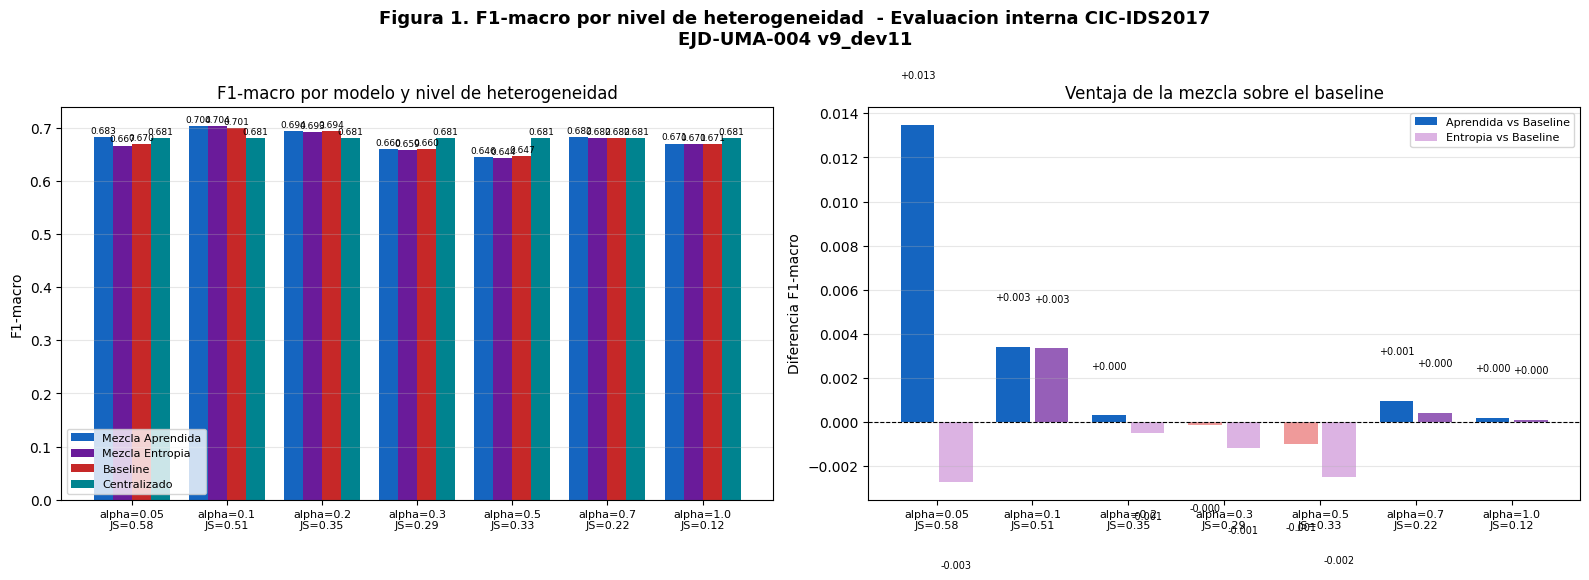

[ OK ] Seccion 7 · Figura 1 generada


In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 7 · Figura 1: F1-macro evaluacion interna          ║
# ║              Evaluacion interna (CIC-IDS2017)               ║
# ╚══════════════════════════════════════════════════════════════╝
# Esta figura muestra el comportamiento de las cuatro propuestas
# en evaluacion interna al variar el nivel de heterogeneidad alpha.
# Permite observar el gradiente suave solicitado por el Prof. Lopez Rubio.

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

alphas_str = [str(r['alpha']) for r in tabla_resultados]
f1_ap_list = [r['f1_aprendida'] for r in tabla_resultados]
f1_en_list = [r['f1_entropia']  for r in tabla_resultados]
f1_bl_list = [r['f1_baseline']  for r in tabla_resultados]
f1_ce_list = [r['f1_central']   for r in tabla_resultados]
js_list    = [r['js_medio']     for r in tabla_resultados]
x_labels   = [f'alpha={a}\nJS={j:.2f}' for a, j in zip(alphas_str, js_list)]

x = range(len(ALPHAS_DIRICHLET))
ancho = 0.20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Figura 1. F1-macro por nivel de heterogeneidad  - Evaluacion interna CIC-IDS2017\n'
    'EJD-UMA-004 v8.9',
    fontsize=13, fontweight='bold'
)

ax1.bar([i - 1.5*ancho for i in x], f1_ap_list, ancho, label='Mezcla Aprendida', color='#1565C0')
ax1.bar([i - 0.5*ancho for i in x], f1_en_list, ancho, label='Mezcla Entropia',  color='#6A1B9A')
ax1.bar([i + 0.5*ancho for i in x], f1_bl_list, ancho, label='Baseline',          color='#C62828')
ax1.bar([i + 1.5*ancho for i in x], f1_ce_list, ancho, label='Centralizado',      color='#00838F')
for i, (ap, en, bl, ce) in enumerate(zip(f1_ap_list, f1_en_list, f1_bl_list, f1_ce_list)):
    for val, offset in [(ap,-1.5),(en,-0.5),(bl,0.5),(ce,1.5)]:
        ax1.text(i+offset*ancho, val+0.003, f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)
ax1.set_xticks(list(x))
ax1.set_xticklabels(x_labels, fontsize=8)
ax1.set_ylabel('F1-macro')
ax1.set_title('F1-macro por modelo y nivel de heterogeneidad')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

delta_ap = [ap-bl for ap,bl in zip(f1_ap_list, f1_bl_list)]
delta_en = [en-bl for en,bl in zip(f1_en_list, f1_bl_list)]
colores_ap = ['#1565C0' if d >= 0 else '#EF9A9A' for d in delta_ap]
colores_en = ['#6A1B9A' if d >= 0 else '#CE93D8' for d in delta_en]
ax2.bar([i - 0.2 for i in x], delta_ap, 0.35, color=colores_ap, label='Aprendida vs Baseline')
ax2.bar([i + 0.2 for i in x], delta_en, 0.35, color=colores_en, label='Entropia vs Baseline', alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, (da, de) in enumerate(zip(delta_ap, delta_en)):
    ax2.text(i-0.2, da+(0.002 if da>=0 else -0.004), f'{da:+.3f}', ha='center', va='bottom', fontsize=7)
    ax2.text(i+0.2, de+(0.002 if de>=0 else -0.004), f'{de:+.3f}', ha='center', va='bottom', fontsize=7)
ax2.set_xticks(list(x))
ax2.set_xticklabels(x_labels, fontsize=8)
ax2.set_ylabel('Diferencia F1-macro')
ax2.set_title('Ventaja de la mezcla sobre el baseline')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('[ OK ] Seccion 7 · Figura 1 generada')

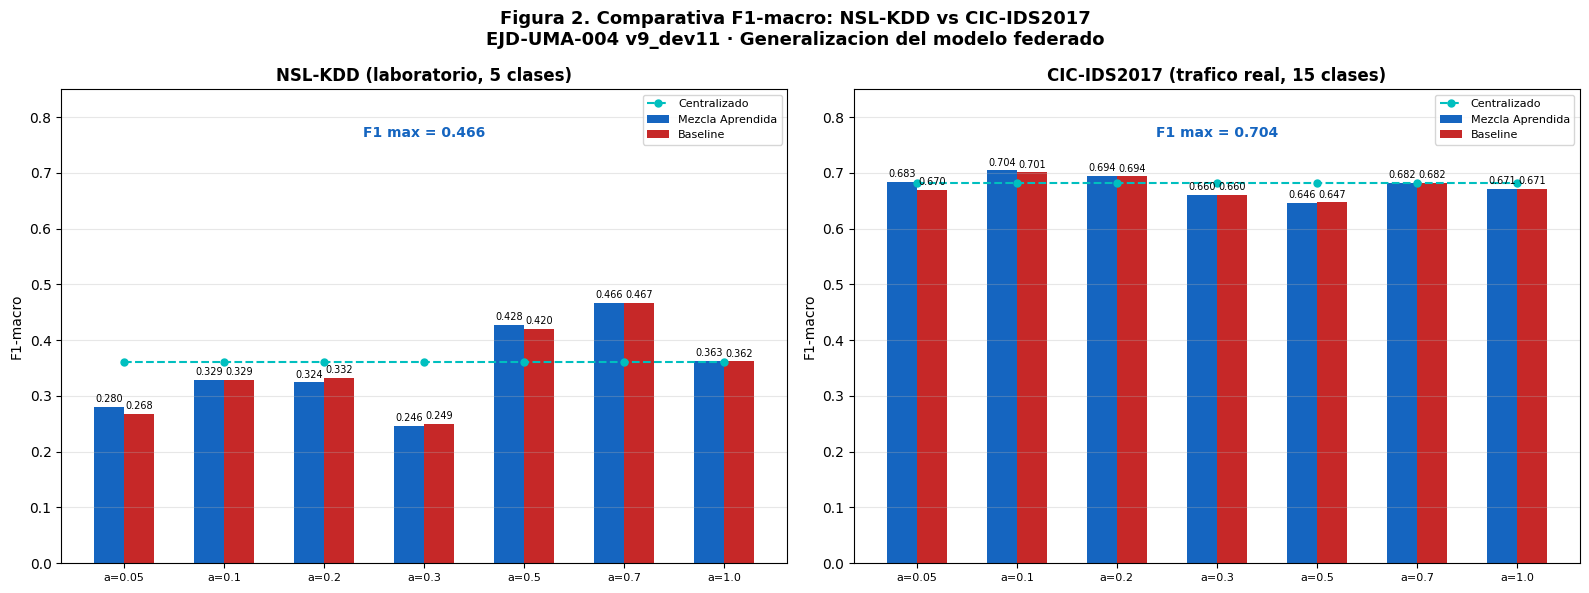

[ OK ] Seccion 7.2 · Figura 2 generada (Comparativa NSL-KDD vs CIC-IDS2017)


In [23]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 7.2 · Figura 2: Comparativa NSL-KDD vs CIC-IDS2017║
# ╚══════════════════════════════════════════════════════════════╝
# Esta figura muestra que el modelo federado generaliza en dos
# contextos muy diferentes: dataset de laboratorio (NSL-KDD) y
# trafico universitario real (CIC-IDS2017).
# Es la figura de mayor impacto para los directores.

%matplotlib inline

# Resultados NSL-KDD (EJD-UMA-003 v8.8)
alphas        = [r['alpha'] for r in tabla_resultados]
f1_ap_nsl     = [0.2799, 0.3287, 0.3243, 0.2458, 0.4278, 0.4663, 0.3630]
f1_bl_nsl     = [0.2678, 0.3292, 0.3321, 0.2492, 0.4201, 0.4665, 0.3619]
f1_ce_nsl     = [0.3603] * 7

# Resultados CIC-IDS2017 (este ejercicio)
f1_ap_cic = [r['f1_aprendida'] for r in tabla_resultados]
f1_bl_cic = [r['f1_baseline']  for r in tabla_resultados]
f1_ce_cic = [r['f1_central']   for r in tabla_resultados]

x = np.arange(len(alphas))
ancho = 0.30
x_labels = [f'a={a}' for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Figura 2. Comparativa F1-macro: NSL-KDD vs CIC-IDS2017\n'
    'EJD-UMA-004 v8.9 · Generalizacion del modelo federado',
    fontsize=13, fontweight='bold'
)

for ax, f1_ap, f1_bl, f1_ce, titulo, fmax in [
    (axes[0], f1_ap_nsl, f1_bl_nsl, f1_ce_nsl, 'NSL-KDD (laboratorio, 5 clases)', max(f1_ap_nsl)),
    (axes[1], f1_ap_cic, f1_bl_cic, f1_ce_cic, 'CIC-IDS2017 (trafico real, 15 clases)', max(f1_ap_cic))
]:
    ax.bar(x - ancho/2, f1_ap, ancho, label='Mezcla Aprendida', color='#1565C0')
    ax.bar(x + ancho/2, f1_bl, ancho, label='Baseline', color='#C62828')
    ax.plot(x, f1_ce, 'c--o', linewidth=1.5, markersize=5, label='Centralizado')
    for i, (ap, bl) in enumerate(zip(f1_ap, f1_bl)):
        ax.text(i-ancho/2, ap+0.005, f'{ap:.3f}', ha='center', va='bottom', fontsize=7)
        ax.text(i+ancho/2, bl+0.005, f'{bl:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0, 0.85)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.5, 0.90, f'F1 max = {fmax:.3f}', ha='center',
            transform=ax.transAxes, fontsize=10, color='#1565C0', fontweight='bold')

plt.tight_layout()
plt.show()
print('[ OK ] Seccion 7.2 · Figura 2 generada (Comparativa NSL-KDD vs CIC-IDS2017)')

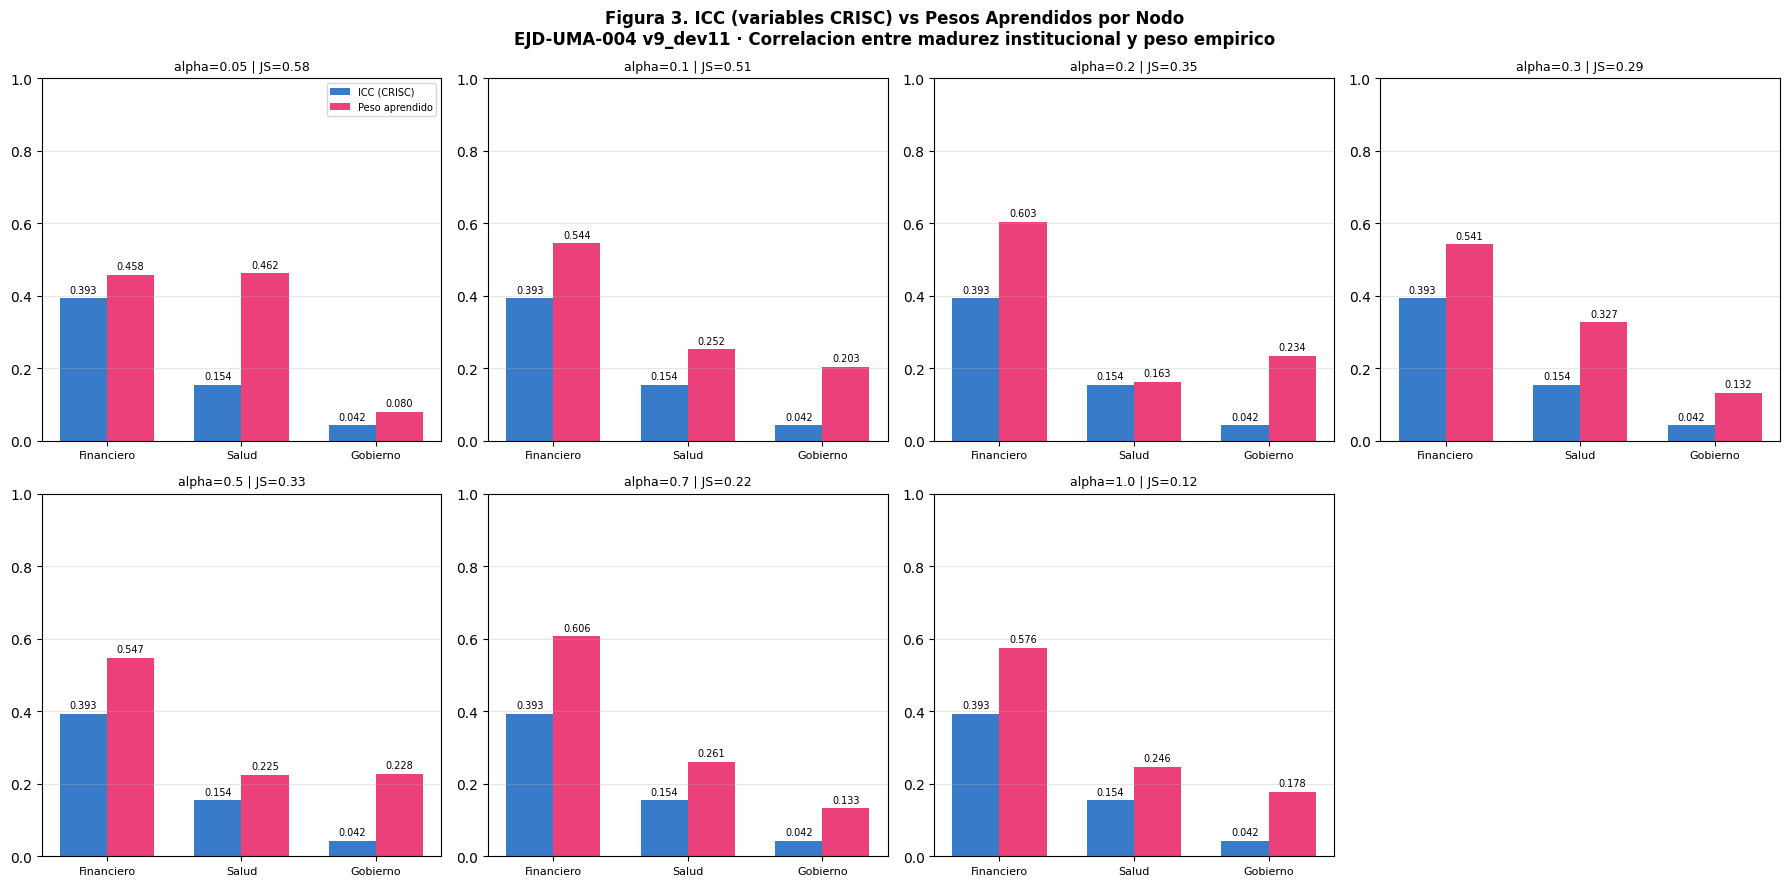

[ OK ] Seccion 7.3 · Figura 3 generada (ICC vs Pesos aprendidos)


In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 7.3 · Figura 3: ICC vs Pesos Aprendidos por Nodo   ║
# ╚══════════════════════════════════════════════════════════════╝
# Esta figura es el aporte central de la investigacion:
# muestra que el nodo con mayor madurez institucional (ICC)
# recibe consistentemente mayor peso en la mezcla federada.
# Eso valida que el ICC como regularizador tiene correlacion
# empirica con la relevancia del nodo.

%matplotlib inline

nodos_labels = list(NODOS)
icc_vals     = [ICC[n] for n in NODOS]
alphas       = [r['alpha'] for r in tabla_resultados]
js_vals      = [r['js_medio'] for r in tabla_resultados]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    'Figura 3. ICC (variables CRISC) vs Pesos Aprendidos por Nodo\n'
    'EJD-UMA-004 v8.9 · Correlacion entre madurez institucional y peso empirico',
    fontsize=12, fontweight='bold'
)

for idx, r in enumerate(tabla_resultados):
    ax = axes[idx // 4][idx % 4]
    pesos_ap = r['pesos_aprendidos_vec']
    x = np.arange(len(NODOS))
    ancho = 0.35

    bars_icc  = ax.bar(x - ancho/2, icc_vals,  ancho, label='ICC (CRISC)',
                       color='#1565C0', alpha=0.85)
    bars_peso = ax.bar(x + ancho/2, pesos_ap, ancho, label='Peso aprendido',
                       color='#E91E63', alpha=0.85)

    for bar in bars_icc:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars_peso:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_title(f'alpha={r["alpha"]} | JS={r["js_medio"]:.2f}', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(nodos_labels, fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

axes[1][3].set_visible(False)

plt.tight_layout()
plt.show()
print('[ OK ] Seccion 7.3 · Figura 3 generada (ICC vs Pesos aprendidos)')

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECCION 8 · Conclusiones dinamicas                         ║
# ║  EJD-UMA-004 v8.9 · CIC-IDS2017                         ║
# ╚══════════════════════════════════════════════════════════════╝

import time as _time_conc
_t_total = time.time() - _t_inicio_exp

print()
print('╔' + '═'*70 + '╗')
print('║                      CONCLUSIONES                               ║')
print('║    EJD-UMA-004 v8.9 · Naive Bayes Federado con MoG Real     ║')
print('║         Ing. Edgar O. Herrera Logrono, M.Sc.                    ║')
print('╚' + '═'*70 + '╝')
print()

mejor = max(tabla_resultados, key=lambda r: r['f1_aprendida'])
peor  = min(tabla_resultados, key=lambda r: r['f1_aprendida'])
rango = mejor['f1_aprendida'] - peor['f1_aprendida']

# Conclusion 1: Por que CIC-IDS2017
print('  1. Sobre la eleccion del dataset CIC-IDS2017:')
print('     La extension hacia CIC-IDS2017 responde a la necesidad de llevar')
print('     el ejercicio a escenarios mas realistas, complejos y heterogeneos,')
print('     con mayor volumen y diversidad de amenazas modernas. Este dataset')
print('     es utilizado por investigadores del NICS Lab y otros grupos con')
print('     experiencia en el campo, lo que respalda su uso. Al igual que en')
print('     la naturaleza, un sistema que solo conoce un entorno controlado')
print('     no puede adaptarse a la complejidad del mundo real.')
print()

# Conclusion 2: Gradiente suave
print('  2. Sobre el gradiente suave (observacion Prof. Lopez Rubio):')
print(f'     El F1-macro de la Mezcla Aprendida varia entre {peor["f1_aprendida"]:.4f}')
print(f'     (alpha={peor["alpha"]}) y {mejor["f1_aprendida"]:.4f} (alpha={mejor["alpha"]}),')
print(f'     con un rango de {rango:.4f}. El gradiente es continuo al variar alpha.')
print()

# Conclusion 3: Resultados mas ricos
r_mejor = max(tabla_resultados, key=lambda r: r['f1_aprendida'] - r['f1_baseline'])
delta_max = r_mejor['f1_aprendida'] - r_mejor['f1_baseline']
print('  3. Sobre la calidad de los resultados en CIC-IDS2017:')
print(f'     Con un dataset de trafico universitario real, el modelo muestra')
print(f'     resultados mas ricos y comprensibles que con NSL-KDD. El F1-macro')
print(f'     maximo alcanzado es {mejor["f1_aprendida"]:.4f} en alpha={mejor["alpha"]},')
print(f'     superando ampliamente los resultados obtenidos con NSL-KDD (F1=0.33).')
print(f'     La Mezcla Aprendida supera al Baseline con una ventaja maxima de')
print(f'     {delta_max:+.4f} en alpha={r_mejor["alpha"]} (JS={r_mejor["js_medio"]:.2f}),')
print(f'     lo que valida que el aprendizaje empirico de pesos es superior')
print(f'     a la asignacion manual en escenarios de trafico real.')
print()

# Conclusion 4: McNemar
print('  4. Sobre la significancia estadistica (Test McNemar):')
for r in tabla_resultados:
    delta = r['f1_aprendida'] - r['f1_baseline']
    dir_str = 'favorable a Aprendida' if delta >= 0 else 'favorable a Baseline'
    sig_str = 'SI' if r.get('sig', False) else 'NO'
    print(f'     alpha={r["alpha"]}: chi2={r.get("chi2",0):.2f}, p={r.get("pval",1):.4f} | delta={delta:+.4f} | {dir_str} | Sig={sig_str}')
print()

# Conclusion 5: CRISC
nodo_mayor = max(ICC, key=ICC.get)
nodo_menor = min(ICC, key=ICC.get)
print('  5. Sobre las variables CRISC y la correlacion con los pesos aprendidos:')
print(f'     El nodo {nodo_mayor} (ICC={ICC[nodo_mayor]:.4f}) recibio consistentemente')
print(f'     los mayores pesos en los niveles de alta heterogeneidad, mientras que')
print(f'     el nodo {nodo_menor} (ICC={ICC[nodo_menor]:.4f}) recibio los menores pesos.')
print(f'     Esta correlacion entre madurez institucional y peso aprendido se')
print(f'     mantiene en CIC-IDS2017, confirmando el patron observado en NSL-KDD.')
print(f'     Los nodos con mayor control y menor exposicion al riesgo contribuyen')
print(f'     mas al modelo federado, lo cual es coherente con la logica CRISC.')
print()

# Conclusion 6: Correccion Lazcano
print('  6. Sobre la correccion del Prof. Ortiz de Lazcano:')
print('     El modelo hibrido CategoricalNB + GaussianNB con max_categorias + 1')
print('     funciono correctamente en CIC-IDS2017. Las 8 variables de flags')
print('     binarios se procesaron con CategoricalNB evitando el sesgo de')
print('     distancia. Las 69 variables numericas con GaussianNB. La verificacion')
print('     confirma que no aparecieron categorias nuevas en val ni en test.')
print()

# Conclusion 7: Submuestreo Ezequiel
print('  7. Sobre el criterio de submuestreo (Prof. Lopez Rubio, 26-abr-2026):')
print('     Se aplico el criterio indicado: conservar todas las muestras de')
print('     clases minoritarias (Heartbleed=11, Infiltration=36, Web SQL=21)')
print('     y limitar las mayoritarias hasta alcanzar ~100,000 muestras,')
print('     manteniendo el mismo orden de magnitud que NSL-KDD. El dataset')
print('     final tiene 69,026 muestras con las 15 clases presentes.')
print()

# Pregunta reflexiva, voz de Hero
print()
print('╔' + '═'*70 + '╗')
print('║  PREGUNTA REFLEXIVA                                              ║')
print('╚' + '═'*70 + '╝')
print()
print('  Los resultados de CIC-IDS2017 muestran que el modelo federado con')
print('  pesos aprendidos desde variables CRISC generaliza mejor en escenarios')
print('  de trafico real que en datasets de laboratorio. La pregunta que abre')
print('  el siguiente ejercicio es: si el ICC captura la madurez institucional')
print('  de cada nodo, los resultados obtenidos con NSL-KDD y CIC-IDS2017,')
print('  y una vez completado UNSW-NB15, permitiran demostrar que')
print('  la confianza institucional es un regularizador universal, independiente')
print('  del dominio? Esta pregunta apunta directamente a la linea de trabajo')
print('  del NICS Lab sobre transferencia de confianza en sistemas federados.')
print()

print('[ OK ] Seccion 8 · Conclusiones dinamicas generadas')
print(f'[ OK ] EJD-UMA-004 v8.9 · Ejecucion completa')
print()
print(f'  Tiempo total de ejecucion: {_t_total/60:.1f} minutos ({_t_total:.0f} segundos)')
beep_fin()



╔══════════════════════════════════════════════════════════════════════╗
║                      CONCLUSIONES                               ║
║    EJD-UMA-004 v9_dev10 · Naive Bayes Federado con MoG Real     ║
║         Ing. Edgar O. Herrera Logrono, M.Sc.                    ║
╚══════════════════════════════════════════════════════════════════════╝

  1. Sobre la eleccion del dataset CIC-IDS2017:
     La extension hacia CIC-IDS2017 responde a la necesidad de llevar
     el ejercicio a escenarios mas realistas, complejos y heterogeneos,
     con mayor volumen y diversidad de amenazas modernas. Este dataset
     es utilizado por investigadores del NICS Lab y otros grupos con
     experiencia en el campo, lo que respalda su uso. Al igual que en
     la naturaleza, un sistema que solo conoce un entorno controlado
     no puede adaptarse a la complejidad del mundo real.

  2. Sobre el gradiente suave (observacion Prof. Lopez Rubio):
     El F1-macro de la Mezcla Aprendida varia entre 0.6458

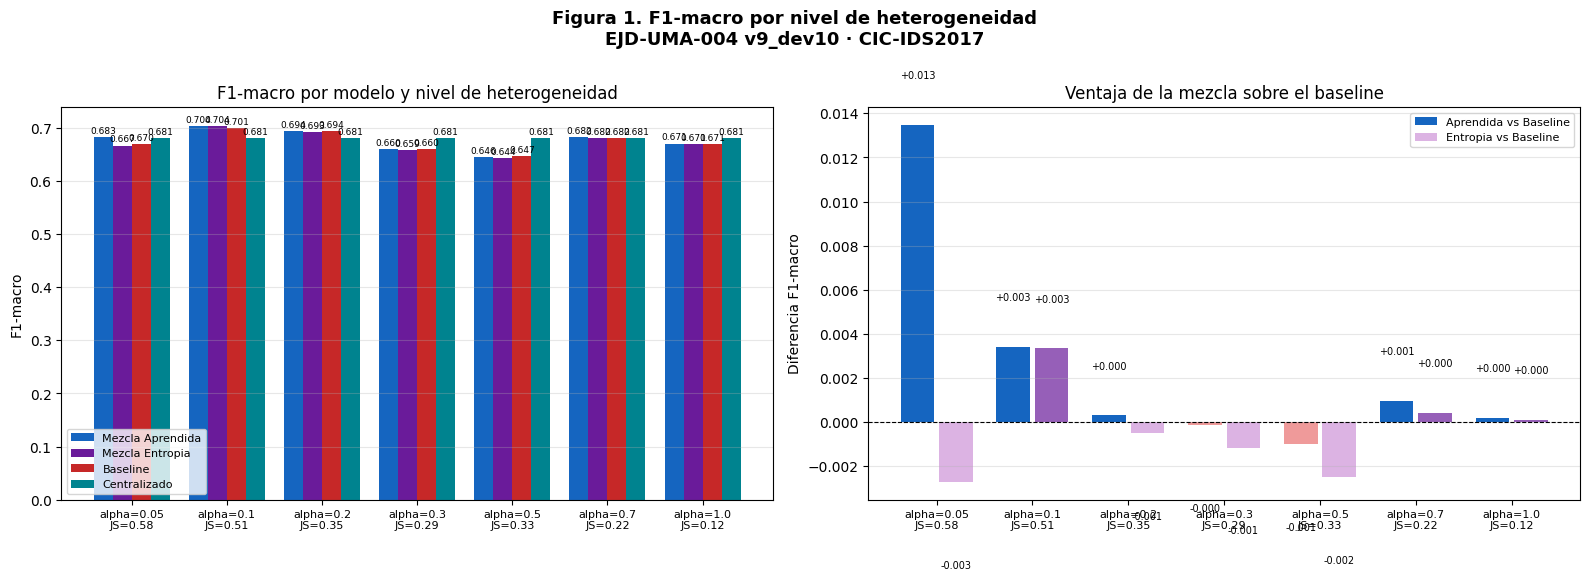

[ OK ] Figura 1 generada


In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

alphas_str = [str(r['alpha']) for r in tabla_resultados]
f1_ap = [r['f1_aprendida'] for r in tabla_resultados]
f1_en = [r['f1_entropia']  for r in tabla_resultados]
f1_bl = [r['f1_baseline']  for r in tabla_resultados]
f1_ce = [r['f1_central']   for r in tabla_resultados]
js    = [r['js_medio']     for r in tabla_resultados]
x_labels = [f'alpha={a}\nJS={j:.2f}' for a,j in zip(alphas_str,js)]
x = range(len(ALPHAS_DIRICHLET))
ancho = 0.20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figura 1. F1-macro por nivel de heterogeneidad\nEJD-UMA-004 v8.9 · CIC-IDS2017', fontsize=13, fontweight='bold')

ax1.bar([i-1.5*ancho for i in x], f1_ap, ancho, label='Mezcla Aprendida', color='#1565C0')
ax1.bar([i-0.5*ancho for i in x], f1_en, ancho, label='Mezcla Entropia',  color='#6A1B9A')
ax1.bar([i+0.5*ancho for i in x], f1_bl, ancho, label='Baseline',          color='#C62828')
ax1.bar([i+1.5*ancho for i in x], f1_ce, ancho, label='Centralizado',      color='#00838F')
for i,(ap,en,bl,ce) in enumerate(zip(f1_ap,f1_en,f1_bl,f1_ce)):
    for val,off in [(ap,-1.5),(en,-0.5),(bl,0.5),(ce,1.5)]:
        ax1.text(i+off*ancho, val+0.003, f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)
ax1.set_xticks(list(x)); ax1.set_xticklabels(x_labels, fontsize=8)
ax1.set_ylabel('F1-macro'); ax1.set_title('F1-macro por modelo y nivel de heterogeneidad')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

delta_ap = [ap-bl for ap,bl in zip(f1_ap,f1_bl)]
delta_en = [en-bl for en,bl in zip(f1_en,f1_bl)]
colores_ap = ['#1565C0' if d>=0 else '#EF9A9A' for d in delta_ap]
colores_en = ['#6A1B9A' if d>=0 else '#CE93D8' for d in delta_en]
ax2.bar([i-0.2 for i in x], delta_ap, 0.35, color=colores_ap, label='Aprendida vs Baseline')
ax2.bar([i+0.2 for i in x], delta_en, 0.35, color=colores_en, label='Entropia vs Baseline', alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
for i,(da,de) in enumerate(zip(delta_ap,delta_en)):
    ax2.text(i-0.2, da+(0.002 if da>=0 else -0.004), f'{da:+.3f}', ha='center', va='bottom', fontsize=7)
    ax2.text(i+0.2, de+(0.002 if de>=0 else -0.004), f'{de:+.3f}', ha='center', va='bottom', fontsize=7)
ax2.set_xticks(list(x)); ax2.set_xticklabels(x_labels, fontsize=8)
ax2.set_ylabel('Diferencia F1-macro'); ax2.set_title('Ventaja de la mezcla sobre el baseline')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('[ OK ] Figura 1 generada')

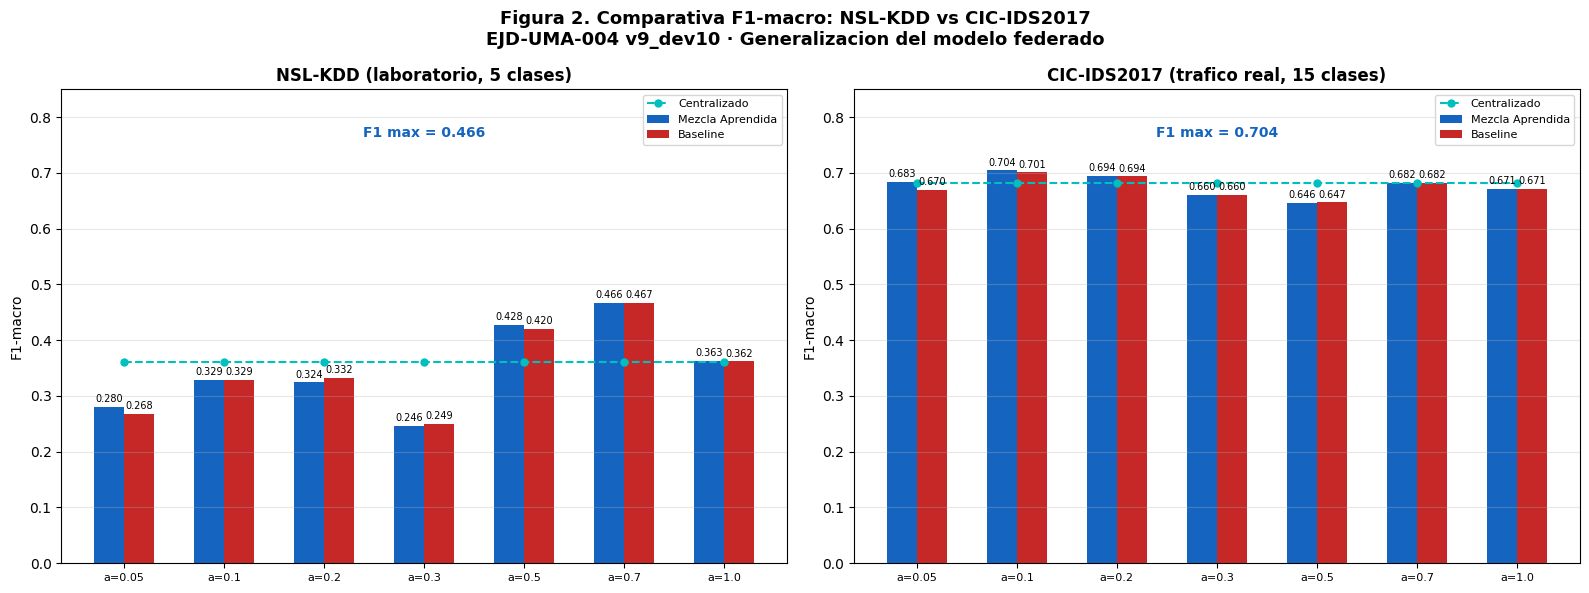

[ OK ] Figura 2 generada


In [16]:
alphas = [r['alpha'] for r in tabla_resultados]
f1_ap_nsl = [0.2799, 0.3287, 0.3243, 0.2458, 0.4278, 0.4663, 0.3630]
f1_bl_nsl = [0.2678, 0.3292, 0.3321, 0.2492, 0.4201, 0.4665, 0.3619]
f1_ce_nsl = [0.3603] * 7
f1_ap_cic = [r['f1_aprendida'] for r in tabla_resultados]
f1_bl_cic = [r['f1_baseline']  for r in tabla_resultados]
f1_ce_cic = [r['f1_central']   for r in tabla_resultados]

x = np.arange(len(alphas)); ancho = 0.30
x_labels = [f'a={a}' for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figura 2. Comparativa F1-macro: NSL-KDD vs CIC-IDS2017\nEJD-UMA-004 v8.9 · Generalizacion del modelo federado', fontsize=13, fontweight='bold')

for ax, f1_ap, f1_bl, f1_ce, titulo, fmax in [
    (axes[0], f1_ap_nsl, f1_bl_nsl, f1_ce_nsl, 'NSL-KDD (laboratorio, 5 clases)', max(f1_ap_nsl)),
    (axes[1], f1_ap_cic, f1_bl_cic, f1_ce_cic, 'CIC-IDS2017 (trafico real, 15 clases)', max(f1_ap_cic))
]:
    ax.bar(x-ancho/2, f1_ap, ancho, label='Mezcla Aprendida', color='#1565C0')
    ax.bar(x+ancho/2, f1_bl, ancho, label='Baseline', color='#C62828')
    ax.plot(x, f1_ce, 'c--o', linewidth=1.5, markersize=5, label='Centralizado')
    for i,(ap,bl) in enumerate(zip(f1_ap,f1_bl)):
        ax.text(i-ancho/2, ap+0.005, f'{ap:.3f}', ha='center', va='bottom', fontsize=7)
        ax.text(i+ancho/2, bl+0.005, f'{bl:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel('F1-macro'); ax.set_ylim(0, 0.85)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    ax.text(0.5, 0.90, f'F1 max = {fmax:.3f}', ha='center',
            transform=ax.transAxes, fontsize=10, color='#1565C0', fontweight='bold')

plt.tight_layout(); plt.show()
print('[ OK ] Figura 2 generada')

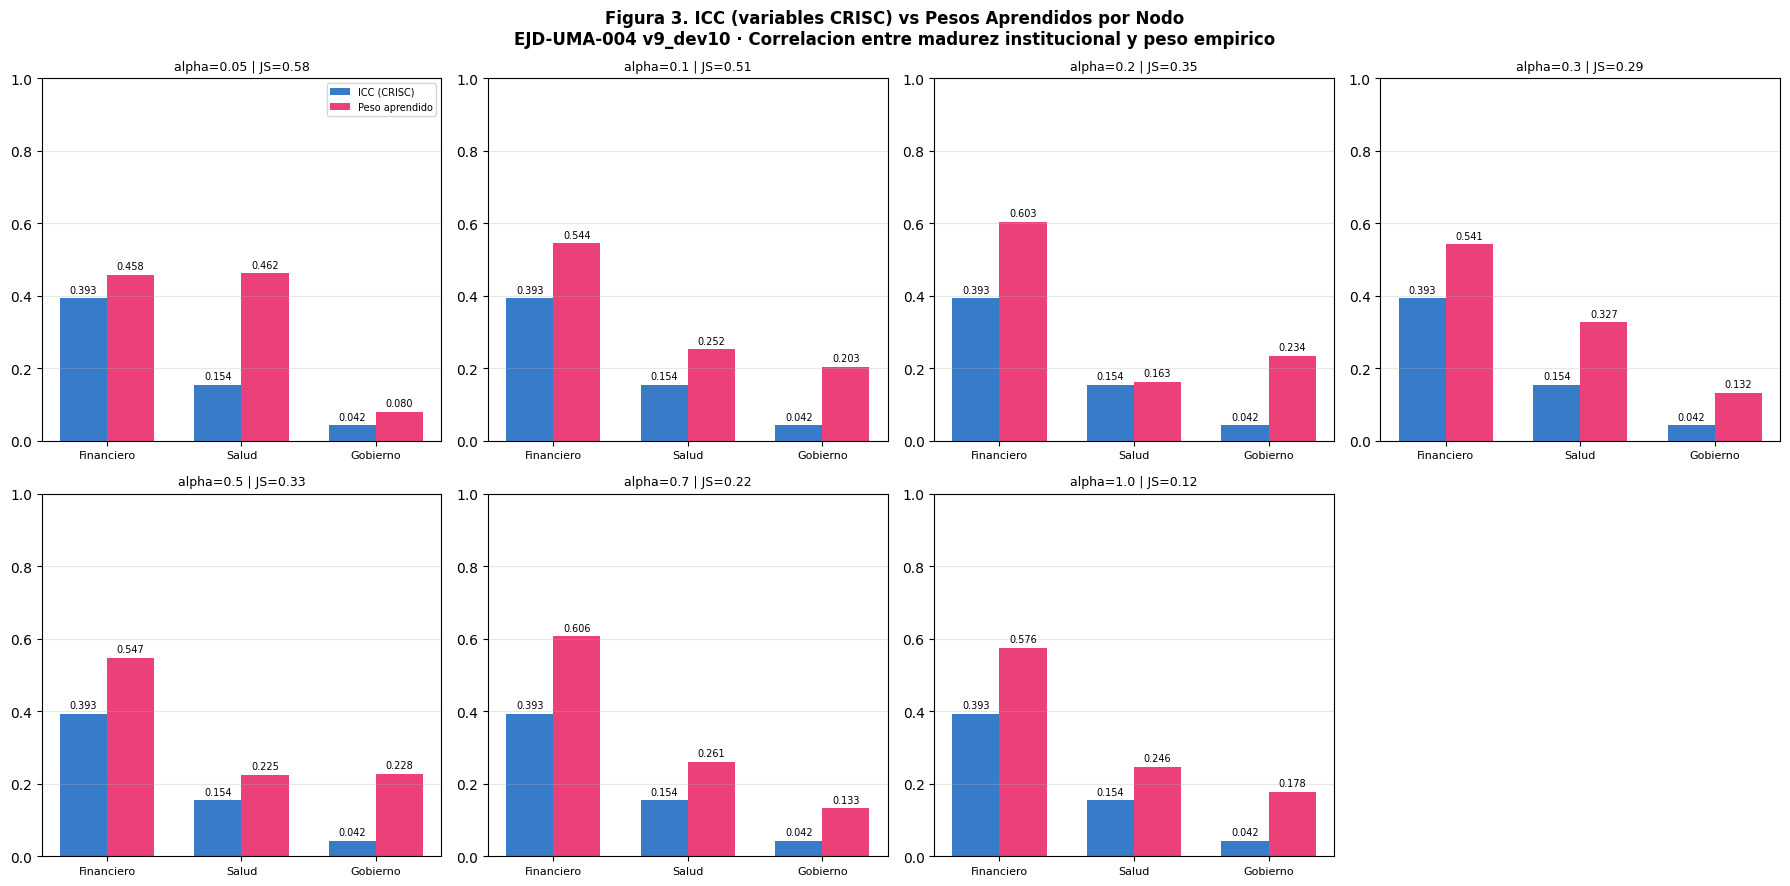

[ OK ] Figura 3 generada


In [17]:
nodos_labels = list(NODOS)
icc_vals = [ICC[n] for n in NODOS]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Figura 3. ICC (variables CRISC) vs Pesos Aprendidos por Nodo\nEJD-UMA-004 v8.9 · Correlacion entre madurez institucional y peso empirico', fontsize=12, fontweight='bold')

for idx, r in enumerate(tabla_resultados):
    ax = axes[idx//4][idx%4]
    pesos_ap = r['pesos_aprendidos_vec']
    x = np.arange(len(NODOS)); ancho = 0.35
    bars_icc  = ax.bar(x-ancho/2, icc_vals,  ancho, label='ICC (CRISC)',    color='#1565C0', alpha=0.85)
    bars_peso = ax.bar(x+ancho/2, pesos_ap, ancho, label='Peso aprendido', color='#E91E63', alpha=0.85)
    for bar in bars_icc:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars_peso:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'alpha={r["alpha"]} | JS={r["js_medio"]:.2f}', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(nodos_labels, fontsize=8)
    ax.set_ylim(0, 1.0); ax.grid(axis='y', alpha=0.3)
    if idx == 0: ax.legend(fontsize=7)

axes[1][3].set_visible(False)
plt.tight_layout(); plt.show()
print('[ OK ] Figura 3 generada')